# 15 — Full Simulation with Ground Truth Comparison

End-to-end simulation with ground truth (real YouGov survey responses) plotted alongside LLM opinion trajectories.

1. Load data & build environment
2. Collect ground truth before simulation
3. Configure & run simulation
4. Plot opinion trajectories **with ground truth overlay**
5. Save results

**LLM model config:** `llm_model` / `llm_provider` are used for broadcast, peer messaging, and memory. To use a different (e.g. more capable) model for surveys, set `survey_model` / `survey_provider`. When `None`, surveys fall back to the main model.

In [9]:
import os, sys, random, logging
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '../src')))
logging.basicConfig(level=logging.INFO, format='%(levelname)s %(message)s')
logging.getLogger("httpx").setLevel(logging.WARNING)
logging.getLogger("httpcore").setLevel(logging.WARNING)

from cag.io.survey import load
from cag.abm.agent import SurveyedCitizen, PoliticalAgent
from cag.abm.environment import SurveyedNation
from cag.abm.attributes.opinion import ClimatePolicyID, SURVEY_QUESTIONS
from cag.abm.sim import run_simulation, save_results, plot_opinion_trajectories, collect_ground_truth

from gabm.abm.attributes.gender import GenderMap, GenderID
from gabm.abm.attributes.politics import PoliticsID
from gabm.abm.democracy.election import ElectionID
from cag.abm.attributes.region import UKRegionMap, RegionID
from cag.abm.attributes.education import SurveyEducationMap, EducationID
from cag.abm.attributes.ethnicity import SurveyEthnicityMap, EthnicityID
from cag.abm.attributes.income import SurveyIncomeMap, IncomeID
from cag.abm.attributes.politics import SurveyPoliticsMap
from cag.abm.attributes.family import SurveyFamilyMap, FamilyID
from cag.abm.democracy.elections.ukge2019 import UKGE2019VoteMap, UKGE2019VoteID
from cag.abm.democracy.elections.brexit import BrexitVoteMap, BrexitVoteID
from cag.abm.attributes.narratives import (
    SelftranscMap, SelfenhMap, OpennessMap, ConformTradMap, SDOMap, EDOMap, RWAMap,
    rescale_1_6, rescale_1_7,
)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Imports OK")

Imports OK


## 1. Load Data & Build Environment

In [10]:
N_CITIZENS = 30
random.seed(42)
year = 2026

UKGE2019_ELECTION_ID = ElectionID(0)
BREXIT_REFERENDUM_ID = ElectionID(1)

sn = SurveyedNation(
    year=year, place="UK",
    gender_map=GenderMap(),
    region_map=UKRegionMap(),
    education_map=SurveyEducationMap(),
    ethnicity_map=SurveyEthnicityMap(),
    income_map=SurveyIncomeMap(),
    politics_map=SurveyPoliticsMap(),
    family_map=SurveyFamilyMap(),
    ukge2019_vote_map=UKGE2019VoteMap(UKGE2019_ELECTION_ID),
    brexit_vote_map=BrexitVoteMap(BREXIT_REFERENDUM_ID),
    selftransc_map=SelftranscMap,
    selfenh_map=SelfenhMap,
    openness_map=OpennessMap,
    conformtrad_map=ConformTradMap,
    sdo_map=SDOMap,
    edo_map=EDOMap,
    rwa_map=RWAMap,
)

data = load("../data/yougov_survey_data/YouGovProcessedData.csv")
data = data.sample(n=N_CITIZENS, random_state=42)

for i in range(len(data)):
    row = data.iloc[i]
    sc = SurveyedCitizen(
        agent_id=row.get('ID', None), environment=sn,
        year_of_birth=year - int(row.get('age', 0)),
        gender_id=GenderID.MALE if int(row.get('male_dummy', 0)) == 1 else GenderID.FEMALE,
        region_id=RegionID(int(row.get('tprofile_GOR', 0))),
        education_id=EducationID(int(row.get('profile_education_level', 0))),
        income_id=IncomeID(int(row.get('tprofile_gross_household', 0))),
        ethnicity_id=EthnicityID(int(row.get('ethnicity_R', 0))),
        family_id=FamilyID.PARENT if int(row.get('parent_dummy', 0)) == 1 else FamilyID.NOT_PARENT,
        ukge2019_vote_id=UKGE2019VoteID(int(row.get('Vote2019R', 0))),
        brexit_vote_id=BrexitVoteID(int(row.get('pastvote_EURef', 0))),
        politics_id=PoliticsID(int(row.get('Political_Left_Right', 0))),
        selftransc_id=rescale_1_6(int(row.get('Selftransc_Val', 0))),
        selfenh_id=rescale_1_6(int(row.get('Selfenh_Values', 0))),
        openness_id=rescale_1_6(int(row.get('Openness', 0))),
        conformtrad_id=rescale_1_6(int(row.get('ConformTrad', 0))),
        sdo_id=rescale_1_7(int(row.get('SDO', 0))),
        edo_id=rescale_1_7(int(row.get('EDO', 0))),
        rwa_id=rescale_1_6(int(row.get('RWA', 0))),
        original_survey_data=data.iloc[i],
    )
    sn.agents_active[sc.id] = sc

print(f"Citizens loaded: {len(sn.agents_active)}")

INFO Columns with NaN counts (before filtering):
tprofile_gross_household    398
Political_Left_Right          6
dtype: int64
INFO Column with most NaNs: tprofile_gross_household (398 NaNs)


INFO 1483 rows after filtering.


Citizens loaded: 30


## 2. Collect Ground Truth

Extract real YouGov survey responses **before** the simulation runs. This DataFrame persists even after the simulation modifies agent state.

In [11]:
# Collect ground truth for all policies (or pass policy_ids=[...] to filter)
gt_df = collect_ground_truth(sn.agents_active.values())

print(f"Ground truth shape: {gt_df.shape}")
print(f"Policies: {gt_df['policy_id'].unique()}")
print(f"\nMean ground truth per policy:")
for pid, grp in gt_df.groupby("policy_id"):
    short = pid.split(".")[-1]
    print(f"  {short:25s}  mean={grp['ground_truth'].mean():+.2f}  SD={grp['ground_truth'].std():.2f}")

gt_df.head()

Ground truth shape: (180, 3)
Policies: <StringArray>
['ClimatePolicyID(1)', 'ClimatePolicyID(2)', 'ClimatePolicyID(3)',
 'ClimatePolicyID(4)', 'ClimatePolicyID(5)', 'ClimatePolicyID(6)']
Length: 6, dtype: str

Mean ground truth per policy:
  ClimatePolicyID(1)         mean=+1.73  SD=1.08
  ClimatePolicyID(2)         mean=+0.57  SD=1.70
  ClimatePolicyID(3)         mean=-0.17  SD=2.10
  ClimatePolicyID(4)         mean=+1.57  SD=1.63
  ClimatePolicyID(5)         mean=+0.50  SD=1.66
  ClimatePolicyID(6)         mean=-0.17  SD=1.60


,agent_id,policy_id,ground_truth
0,165.0,ClimatePolicyID(1),2
1,165.0,ClimatePolicyID(2),0
2,165.0,ClimatePolicyID(3),0
3,165.0,ClimatePolicyID(4),1
4,165.0,ClimatePolicyID(5),1


## 3. Configure & Run Simulation

Edit `config` below to change policy, phases, model, days, etc.

In [12]:
POLICY = ClimatePolicyID.CARBON_TAX

config = {
    "n_citizens": N_CITIZENS,
    "days": [
        {"policy": POLICY, "phases": ["P-A", "P-B", "C"]},
    ]*5,  # repeat the same policy for multiple days to get more data points
    "k_peers_per_day": 3,
    "llm_model": "gpt-4o-mini",         # broadcast, peer messaging, memory
    "llm_provider": "openai",
    "llm_temperature": 0.5,
    "survey_model": "claude-sonnet-4-6",          # uncomment to use a different model for surveys
    "survey_provider": "anthropic",       # uncomment if survey model is from a different provider
    "thinking": True,
    "debias": True,
    "p_intra": 0.15,
    "p_inter": 0.02,
    "random_seed": 42,
}

print(f"Config: {len(config['days'])} days, {N_CITIZENS} citizens")
print(f"Model: {config['llm_model']} ({config['llm_provider']})")
print(f"Survey model: {config.get('survey_model', 'same as main')}")
print(f"Policy: {POLICY}")
print(f"Debias: {config['debias']}")

Config: 5 days, 30 citizens
Model: gpt-4o-mini (openai)
Survey model: claude-sonnet-4-6
Policy: ClimatePolicyID(5)
Debias: True


In [13]:
results = run_simulation(config, sn)
print(f"\nSimulation complete.")
print(f"Opinion trajectories: {len(results['opinion_trajectories'])} rows")
print(f"Reflections: {len(results['reflections'])} rows")

INFO Simulation: 30 agents, 5 days
INFO Running baseline survey (day 0), policy=ClimatePolicyID(5)
INFO --- Day 1/5 (policy=ClimatePolicyID(5), phases=['P-A', 'P-B', 'C']) ---
INFO [P-A] Day 1: delivered message to 23 citizens. Message (first 120 chars): As we face the intertwined crises of climate change and rising living costs, it’s crucial that we take bold, transformat...
INFO [P-A] Sample reflection: This message resonates with my belief in the importance of equal opportunity and environmental respect. The idea of a carbon tax seems like a proactive way to address climate change while also conside...
INFO [P-B] Day 1: delivered message to 21 citizens. Message (first 120 chars): Let’s be clear: a carbon tax is nothing more than a cash grab by the Westminster elite, disguised as a green initiative....
INFO [P-B] Sample reflection: Reading this message has certainly sparked some thoughts and concerns regarding the idea of a carbon tax. On one hand, I understand the importance of addr


Simulation complete.
Opinion trajectories: 180 rows
Reflections: 359 rows


## 4. Opinion Trajectories

In [14]:
df_traj = results["opinion_trajectories"]
print(f"Shape: {df_traj.shape}")
print(f"Days: {sorted(df_traj['day'].unique())}")
print(f"Policies: {df_traj['policy_id'].unique()}")

# Mean opinion by day
print("\nMean opinion by day:")
for day, val in df_traj.groupby("day")["numeric"].mean().items():
    print(f"  Day {int(day)}: {val:+.2f}")

df_traj.head(10)

Shape: (180, 4)
Days: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Policies: <StringArray>
['ClimatePolicyID(5)']
Length: 1, dtype: str

Mean opinion by day:
  Day 0: +1.37
  Day 1: +1.00
  Day 2: +1.10
  Day 3: +0.47
  Day 4: +0.77
  Day 5: +0.97


,agent_id,day,policy_id,numeric
0,165.0,0,ClimatePolicyID(5),-2
1,165.0,1,ClimatePolicyID(5),-1
2,165.0,2,ClimatePolicyID(5),0
3,165.0,3,ClimatePolicyID(5),-2
4,165.0,4,ClimatePolicyID(5),-2
5,165.0,5,ClimatePolicyID(5),1
6,582.0,0,ClimatePolicyID(5),2
7,582.0,1,ClimatePolicyID(5),1
8,582.0,2,ClimatePolicyID(5),1
9,582.0,3,ClimatePolicyID(5),1


## 5. Plot: Opinion Trajectories with Ground Truth

Each thin line is one agent's LLM trajectory. The **black line** is the LLM mean. The **red dashed line** is the ground truth mean. Red dots show individual ground truth values (jittered at day −0.3 for visibility).

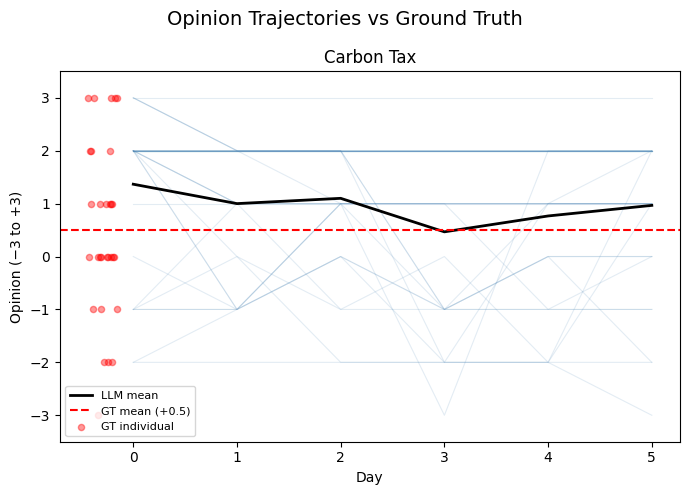

In [15]:
POLICY_SHORT_NAMES = {
    str(ClimatePolicyID.RENEWABLE_ENERGY): "Renewable Energy",
    str(ClimatePolicyID.BAN_FOSSIL_FUEL): "Ban Fossil Fuels",
    str(ClimatePolicyID.BAN_PETROL_CARS): "Ban Petrol Cars",
    str(ClimatePolicyID.GREEN_HOUSING): "Green Housing",
    str(ClimatePolicyID.CARBON_TAX): "Carbon Tax",
    str(ClimatePolicyID.CLIMATE_COMPENSATION): "Climate Compensation",
}

policies_in_sim = df_traj["policy_id"].unique()
n_policies = len(policies_in_sim)
ncols = min(n_policies, 3)
nrows = (n_policies + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows), squeeze=False)

for i, pid in enumerate(policies_in_sim):
    ax = axes[i // ncols, i % ncols]
    pdf = df_traj[df_traj["policy_id"] == pid]

    # Individual agent trajectories
    for agent_id in pdf["agent_id"].unique():
        ad = pdf[pdf["agent_id"] == agent_id].sort_values("day")
        ax.plot(ad["day"], ad["numeric"], alpha=0.15, color="steelblue", linewidth=0.8)

    # LLM mean trajectory
    llm_mean = pdf.groupby("day")["numeric"].mean()
    ax.plot(llm_mean.index, llm_mean.values, color="black", linewidth=2, label="LLM mean")

    # Ground truth for this policy
    gt_policy = gt_df[gt_df["policy_id"] == pid]
    if not gt_policy.empty:
        gt_vals = gt_policy["ground_truth"].values
        gt_mean = gt_vals.mean()

        # GT mean as horizontal dashed line
        ax.axhline(gt_mean, color="red", linestyle="--", linewidth=1.5, label=f"GT mean ({gt_mean:+.1f})")

        # Individual GT values as jittered dots at day -0.3
        jitter = np.random.default_rng(42).uniform(-0.15, 0.15, len(gt_vals))
        ax.scatter(
            np.full(len(gt_vals), -0.3) + jitter, gt_vals,
            color="red", alpha=0.4, s=20, zorder=5, label="GT individual",
        )

    ax.set_xlabel("Day")
    ax.set_ylabel("Opinion (−3 to +3)")
    ax.set_ylim(-3.5, 3.5)
    ax.set_title(POLICY_SHORT_NAMES.get(pid, pid)[:50])
    ax.legend(fontsize=8)

# Hide unused subplots
for i in range(n_policies, nrows * ncols):
    axes[i // ncols, i % ncols].set_visible(False)

fig.suptitle("Opinion Trajectories vs Ground Truth", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Baseline Bias: Day 0 vs Ground Truth

Per-agent scatter — how far does the LLM's first response (day 0) deviate from the real survey answer?

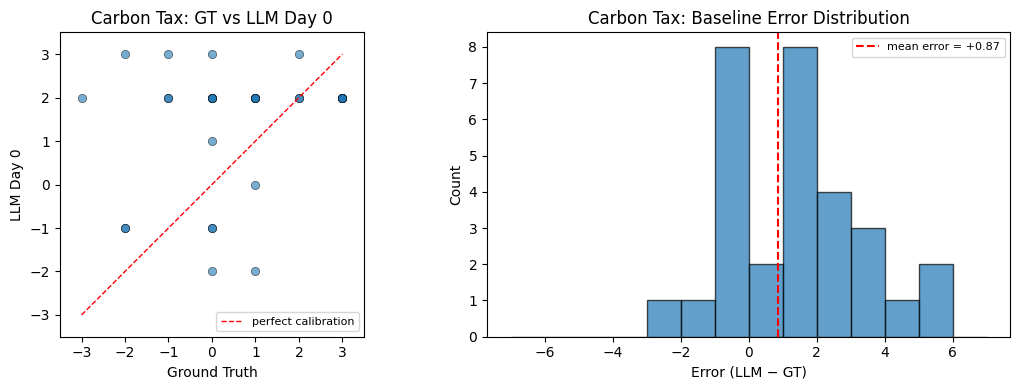

Carbon Tax: MAE=1.73, Mean Error=+0.87, N=30


In [16]:
# Merge day-0 LLM opinions with ground truth
day0 = df_traj[df_traj["day"] == 0].copy()
merged = day0.merge(gt_df, on=["agent_id", "policy_id"], how="inner")
merged["error"] = merged["numeric"] - merged["ground_truth"]

for pid in merged["policy_id"].unique():
    sub = merged[merged["policy_id"] == pid]
    short = POLICY_SHORT_NAMES.get(pid, pid)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

    # Scatter: GT vs LLM day 0
    ax1.scatter(sub["ground_truth"], sub["numeric"], alpha=0.6, edgecolors="k", linewidth=0.5)
    ax1.plot([-3, 3], [-3, 3], "r--", linewidth=1, label="perfect calibration")
    ax1.set_xlabel("Ground Truth")
    ax1.set_ylabel("LLM Day 0")
    ax1.set_xlim(-3.5, 3.5)
    ax1.set_ylim(-3.5, 3.5)
    ax1.set_title(f"{short}: GT vs LLM Day 0")
    ax1.legend(fontsize=8)
    ax1.set_aspect("equal")

    # Error distribution
    ax2.hist(sub["error"], bins=range(-7, 8), edgecolor="k", alpha=0.7)
    ax2.axvline(sub["error"].mean(), color="red", linestyle="--",
                label=f"mean error = {sub['error'].mean():+.2f}")
    ax2.set_xlabel("Error (LLM − GT)")
    ax2.set_ylabel("Count")
    ax2.set_title(f"{short}: Baseline Error Distribution")
    ax2.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

    mae = sub["error"].abs().mean()
    print(f"{short}: MAE={mae:.2f}, Mean Error={sub['error'].mean():+.2f}, N={len(sub)}")

## 7. Reflections Summary

In [17]:
df_ref = results["reflections"]
print(f"Reflections: {len(df_ref)} total")
print(f"\nPer phase:")
print(df_ref["phase"].value_counts().to_string())
print(f"\nPer day:")
print(df_ref["day"].value_counts().sort_index().to_string())

# Sample one reflection per phase
for phase in ["P-A", "P-B", "C"]:
    subset = df_ref[df_ref["phase"] == phase]
    if subset.empty:
        print(f"\n--- {phase}: no reflections ---")
        continue
    sample = subset.iloc[0]
    print(f"\n--- {phase} (day {int(sample['day'])}, agent {sample['agent_id']}) ---")
    print(sample["text"][:300])

Reflections: 359 total

Per phase:
phase
C      139
P-A    115
P-B    105

Per day:
day
1    72
2    72
3    71
4    72
5    72

--- P-A (day 1, agent 582.0) ---
This message resonates with my belief in the importance of equal opportunity and environmental respect. The idea of a carbon tax seems like a proactive way to address climate change while also considering the financial pressures many families face. The notion of redistributing the revenues to the pu

--- P-B (day 1, agent 165.0) ---
Reading this message has certainly sparked some thoughts and concerns regarding the idea of a carbon tax. On one hand, I understand the importance of addressing climate change and the need for sustainable practices. However, I also resonate with the sentiment that such a tax could disproportionately

--- C (day 1, agent 165.0) ---
Reading my peers' thoughts on the carbon tax has definitely resonated with some of my own concerns and considerations. I appreciate that they all see the potential benefi

## 8. Save Results

In [18]:
out_path = save_results(results, output_dir="../data/output/experiments")
print(f"Saved to: {out_path}")

# Also save ground truth alongside the experiment
gt_df.to_csv(out_path / "ground_truth.csv", index=False)
print(f"  ground_truth.csv: {(out_path / 'ground_truth.csv').stat().st_size:,} bytes")

for fname in ["opinion_trajectories.csv", "reflections.csv", "config.json"]:
    path = out_path / fname
    print(f"  {fname}: {path.stat().st_size:,} bytes")

INFO Results saved to ../data/output/experiments/20260419_204851


Saved to: ../data/output/experiments/20260419_204851
  ground_truth.csv: 4,994 bytes
  opinion_trajectories.csv: 5,351 bytes
  reflections.csv: 398,569 bytes
  config.json: 1,015 bytes


## 9. LLM Call Estimate

In [19]:
n_agents = len(sn.agents_active)
n_a = len(sn.political_agent_a.connected_citizens)
n_b = len(sn.political_agent_b.connected_citizens)
n_days = len(config["days"])
debias_mult = 2 if config.get("debias", False) else 1

# Per day: generate_message(2) + broadcast_reflections(n_a + n_b)
#        + peer_messages(n) + peer_reflections(n) + survey(n * debias_mult)
#        + memory_compression(n)
per_day = 2 + n_a + n_b + n_agents + n_agents + (n_agents * debias_mult) + n_agents
baseline = n_agents * debias_mult  # day 0 survey
total = baseline + per_day * n_days

print(f"Agents: {n_agents} (A-connected: {n_a}, B-connected: {n_b})")
print(f"Debias: {config.get('debias', False)} (×{debias_mult} survey calls)")
print(f"Baseline (day 0): {baseline} calls")
print(f"Per day: ~{per_day} calls")
print(f"Total for {n_days} days: ~{total} LLM calls")

Agents: 30 (A-connected: 23, B-connected: 21)
Debias: True (×2 survey calls)
Baseline (day 0): 60 calls
Per day: ~196 calls
Total for 5 days: ~1040 LLM calls
